## setup

In [49]:
%load_ext autoreload
%autoreload 2

import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from src.extraction import load_processed, save_model, save_processed
from src.clustering import kmeans_grid_search ,apply_pca, check_cluster_balance, RANDOM_STATE, fit_final_kmeans, attach_labels, dbscan_grid_search, fit_final_dbscan, clustering_metrics, compare_methods, choose_method, set_cluster_final, plot_clusters_2d, cluster_profile_standardized, plot_cluster_profile_heatmap, cluster_profile_real, plot_key_features_by_cluster, assign_names, create_target, plot_segment_sizes
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans


sys.path.append("..")
df_prepare_clustering = load_processed("df_prepare_clustering.csv")
df_prepare_clustering.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(8949, 7)

## run the grid search

In [50]:
grid_kmeans = kmeans_grid_search(df_prepare_clustering)
grid_kmeans.head(10)

,n_components,k,explained_variance,inertia,silhouette,min_cluster_pct,max_cluster_pct
0,2,3,0.646,13244.2,0.4487,27.1,37.9
1,2,2,0.646,23542.4,0.4310,31.3,68.7
2,2,4,0.646,10415.0,0.4217,19.3,30.8
3,2,5,0.646,8243.0,0.4101,15.6,27.7
4,3,6,0.760,11704.7,0.3986,5.8,23.3
5,2,7,0.646,5635.0,0.3979,11.0,19.8
6,2,6,0.646,6689.6,0.3947,11.9,27.0
7,3,5,0.760,13781.0,0.3909,15.8,24.2
8,3,4,0.760,16448.3,0.3888,20.9,27.9
9,3,3,0.760,20205.7,0.3826,26.7,39.9


## silhouette heatmap (components × k)

k,2,3,4,5,6,7
n_components,,,,,,
2,0.4310,0.4487,0.4217,0.4101,0.3947,0.3979
3,0.3683,0.3826,0.3888,0.3909,0.3986,0.3467
4,0.3246,0.3340,0.3266,0.3259,0.3287,0.3048
5,0.3046,0.3097,0.3066,0.3248,0.3208,0.2921


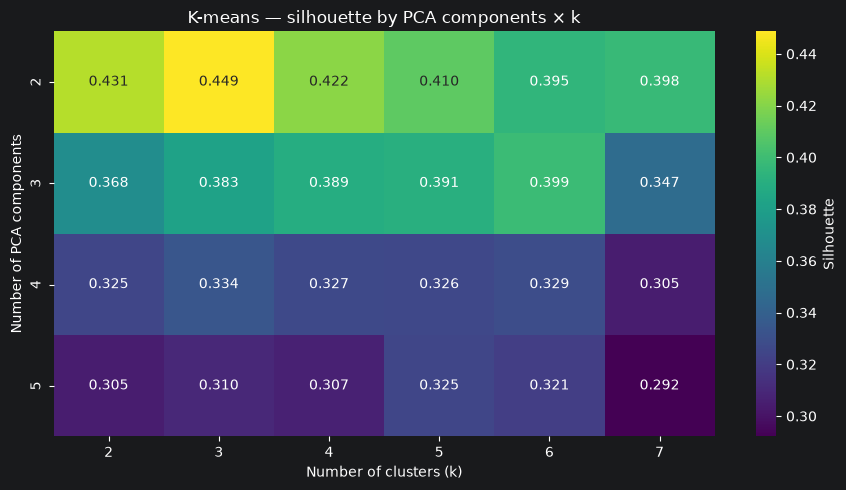

In [51]:
heatmap_data = grid_kmeans.pivot(index="n_components", columns="k", values="silhouette")
display(heatmap_data)

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", cbar_kws={"label" : "Silhouette"})
plt.title("K-means — silhouette by PCA components × k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Number of PCA components")
plt.tight_layout()
plt.savefig("../reports/figures/03_kmeans_grid_heatmap.png", dpi=100)
plt.show()

## Silhouette Interpretation
    > 0.5 Clear separation
    0.3 – 0.5 Reasonable structure
    < 0.25 Weak, clusters overlap

## best combinations that are also balanced

In [52]:
balanced = grid_kmeans[grid_kmeans["min_cluster_pct"] >= 10]
balanced.head(5)


,n_components,k,explained_variance,inertia,silhouette,min_cluster_pct,max_cluster_pct
0,2,3,0.646,13244.2,0.4487,27.1,37.9
1,2,2,0.646,23542.4,0.4310,31.3,68.7
2,2,4,0.646,10415.0,0.4217,19.3,30.8
3,2,5,0.646,8243.0,0.4101,15.6,27.7
5,2,7,0.646,5635.0,0.3979,11.0,19.8


## choose the number of components to study

In [53]:
best = balanced.iloc[0] # <- the best balanced combination.

N_COMPONENTS = int(best["n_components"])
K_CHOSEN = int(best["k"])

curves = grid_kmeans[grid_kmeans["n_components"] == N_COMPONENTS].sort_values("k")
curves[["k", "inertia", "silhouette", "min_cluster_pct", "max_cluster_pct"]]

,k,inertia,silhouette,min_cluster_pct,max_cluster_pct
1,2,23542.4,0.4310,31.3,68.7
0,3,13244.2,0.4487,27.1,37.9
2,4,10415.0,0.4217,19.3,30.8
3,5,8243.0,0.4101,15.6,27.7
6,6,6689.6,0.3947,11.9,27.0
5,7,5635.0,0.3979,11.0,19.8


## elbow curve and silhouette curve

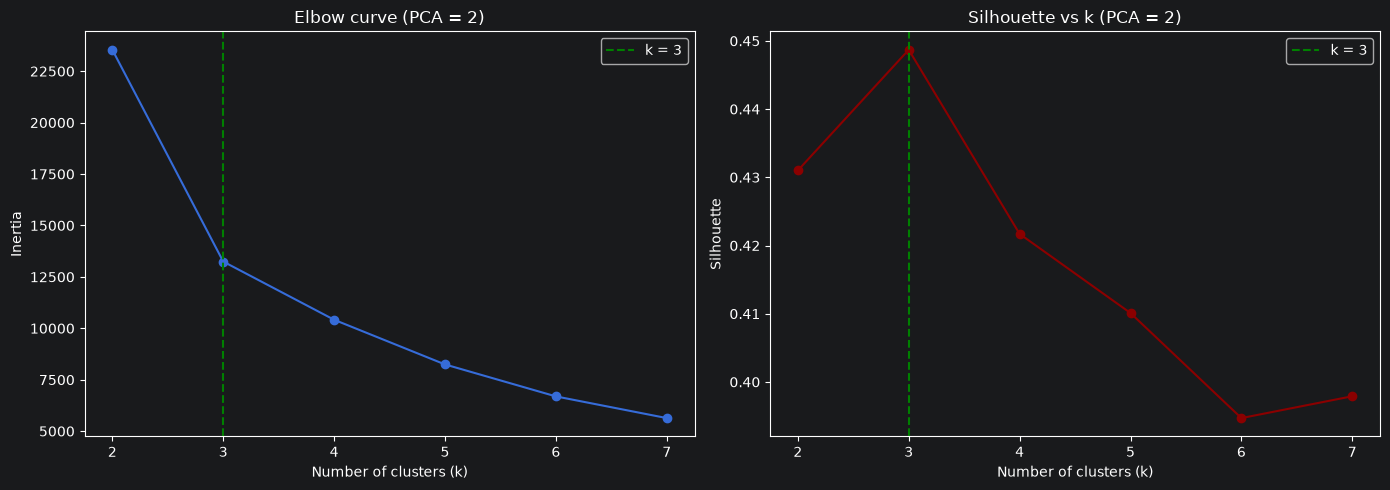

In [54]:
fix, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow: inertia vs k
axes[0].plot(curves["k"], curves["inertia"], marker="o")
axes[0].axvline(K_CHOSEN, color="green", linestyle="--", label=f"k = {K_CHOSEN}")
axes[0].set_title(f"Elbow curve (PCA = {N_COMPONENTS})")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].legend()

# Silhouette vs k
axes[1].plot(curves["k"], curves["silhouette"], marker="o", color="darkred")
axes[1].axvline(K_CHOSEN, color="green", linestyle="--", label=f"k = {K_CHOSEN}")
axes[1].set_title(f"Silhouette vs k (PCA = {N_COMPONENTS})")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/04_elbow_silhouette.png", dpi=100)
plt.show()

## balance check on the chosen combination

In [55]:
df_pca, _ = apply_pca(df_prepare_clustering, N_COMPONENTS)
labels = KMeans(n_clusters=K_CHOSEN, n_init=10, random_state=RANDOM_STATE).fit_predict(df_pca)

sizes, is_balanced = check_cluster_balance(labels)
print(f"balanced {is_balanced}")
sizes

balanced True


,count,pct
cluster,,
0,2428,27.1
1,3393,37.9
2,3128,35.0


## cluster sizes chart

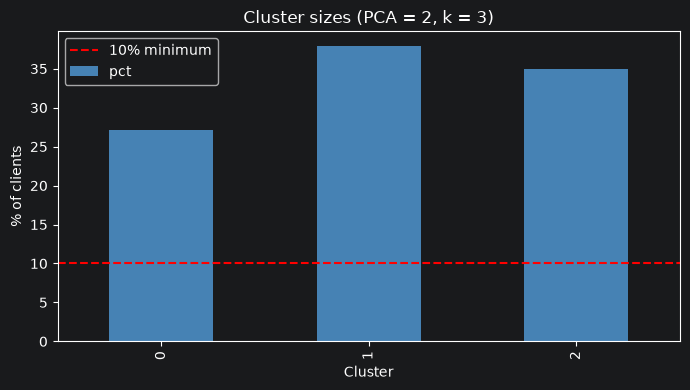

In [56]:
ax = sizes["pct"].plot(kind="bar", figsize=(7, 4), color="steelblue")
ax.axhline(10, color="red", linestyle="--", label="10% minimum")
ax.set_title(f"Cluster sizes (PCA = {N_COMPONENTS}, k = {K_CHOSEN})")
ax.set_xlabel("Cluster")
ax.set_ylabel("% of clients")
ax.legend()
plt.tight_layout()
plt.show()

## fit the final K-means

In [57]:
df_clean = load_processed("df_clean.csv")

labels, kmeans, pca_kmeans, df_pca_kmeans = fit_final_kmeans(df_prepare_clustering, N_COMPONENTS, K_CHOSEN)

## attach the labels to df_clean

In [58]:
df_clean = attach_labels(df_clean, labels, "cluster_kmeans")
df_clean.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,cluster_kmeans
0,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084,2
1,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597,0
2,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742,1
3,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000,2
4,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763,2


## scatterplot

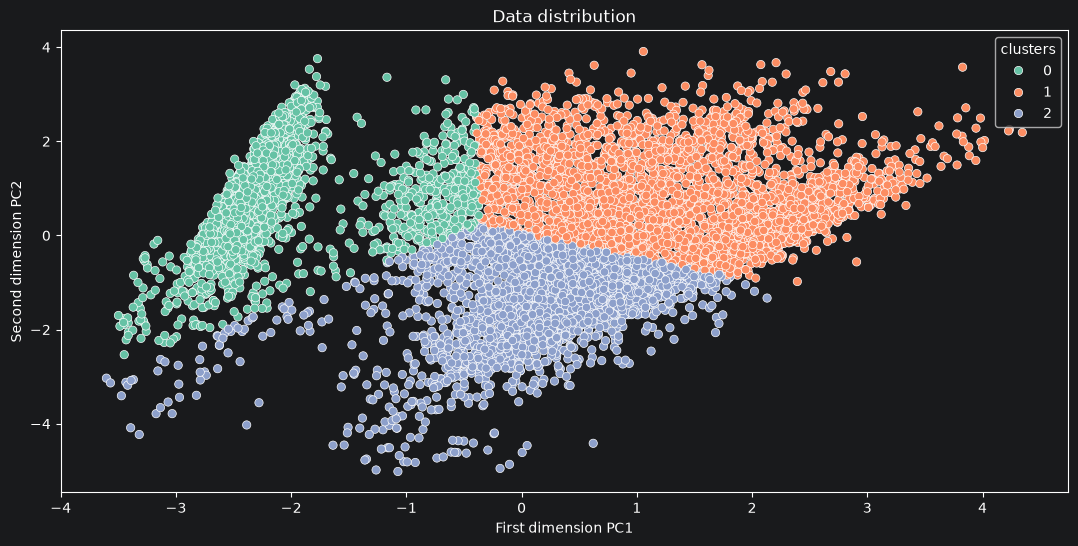

In [59]:
df_pca_labels = attach_labels(df_pca_kmeans, labels, "clusters")

plt.figure(figsize=(13, 6))
sns.scatterplot(x="PC1", y="PC2", data=df_pca_labels, hue="clusters", palette="Set2")
plt.title("Data distribution")
plt.xlabel("First dimension PC1")
plt.ylabel("Second dimension PC2")
plt.show()


## save the result

In [60]:
save_processed(df_clean, "df_clean_clusters.csv")

PosixPath('/home/ouelaimar/Desktop/CardProfiler/data/processed/df_clean_clusters.csv')

## k-distance plot to check the eps range

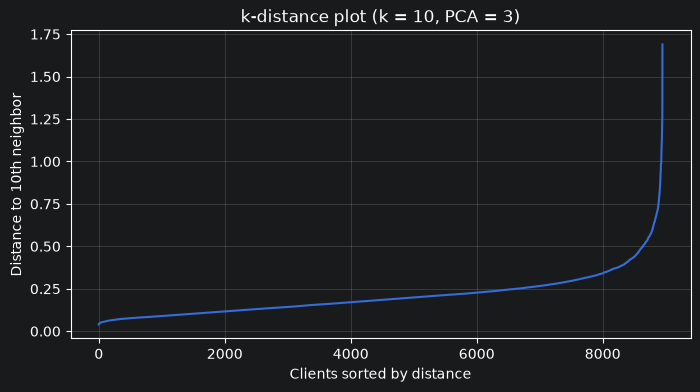

In [61]:
df_pca3, _ = apply_pca(df_prepare_clustering, 3)
MIN_SAMPLES = 10

distances, _ = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(df_pca3).kneighbors(df_pca3)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.title(f"k-distance plot (k = {MIN_SAMPLES}, PCA = 3)")
plt.xlabel("Clients sorted by distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}th neighbor")
plt.grid(alpha=0.3)
plt.show()


## run the grid search

In [62]:
grid_dbscan = dbscan_grid_search(df_prepare_clustering)
grid_dbscan


,n_components,eps,min_samples,n_clusters,noise_pct,silhouette,min_cluster_pct,max_cluster_pct
0,3,0.3,50,4,44.5,0.6320,7.2,20.4
1,4,0.3,50,3,77.2,0.6294,2.3,17.3
2,5,0.5,50,5,59.9,0.5234,0.6,19.2
3,4,0.3,20,7,62.1,0.5097,0.2,19.2
4,5,0.3,20,7,73.7,0.5066,0.2,16.9
...,...,...,...,...,...,...,...,...
91,4,1.6,50,1,0.0,NaN,100.0,100.0
92,5,1.0,50,1,4.5,NaN,95.5,95.5
93,5,1.3,50,1,3.1,NaN,96.9,96.9
94,5,1.6,5,1,0.0,NaN,100.0,100.0


## usable combinations only

In [63]:
usable = grid_dbscan[
    (grid_dbscan["n_clusters"] >= 2)
    & (grid_dbscan["noise_pct"] < 5)
    & (grid_dbscan["min_cluster_pct"] >= 10)
]
print(f"{len(usable)} usable combinations out of {len(grid_dbscan)}")
usable.head(10)


0 usable combinations out of 96


,n_components,eps,min_samples,n_clusters,noise_pct,silhouette,min_cluster_pct,max_cluster_pct


## retained parameters

In [64]:
compromise = (
    grid_dbscan[(grid_dbscan["n_clusters"] >= 2) & (grid_dbscan["n_components"] == 2) & (grid_dbscan["silhouette"].notna())].sort_values(["noise_pct", "silhouette"], ascending=[True, False])
)
compromise.head(10)


,n_components,eps,min_samples,n_clusters,noise_pct,silhouette,min_cluster_pct,max_cluster_pct
10,2,0.3,10,3,1.0,0.3952,0.1,76.2
9,2,0.3,20,3,2.6,0.4059,0.3,74.9
5,2,0.3,50,2,6.6,0.4744,21.0,72.4


## fit the final DBSCAN

In [65]:
best = compromise.iloc[0]

DBSCAN_COMPONENTS = int(best["n_components"])
DBSCAN_EPS = float(best["eps"])
DBSCAN_MIN_SAMPLES = int(best["min_samples"])

labels_dbscan, dbscan, df_pca_dbscan = fit_final_dbscan(
    df_prepare_clustering, DBSCAN_COMPONENTS, DBSCAN_EPS, DBSCAN_MIN_SAMPLES
)


## attach both columns to df_clean

In [66]:
df_clean = load_processed("df_clean_clusters.csv")
df_clean = attach_labels(df_clean, labels_dbscan, "cluster_dbscan")
df_clean["est_atypique_dbscan"] = df_clean["cluster_dbscan"] == -1

df_clean[["cluster_kmeans", "cluster_dbscan", "est_atypique_dbscan"]]


,cluster_kmeans,cluster_dbscan,est_atypique_dbscan
0,2,0,False
1,0,1,False
2,1,0,False
3,2,0,False
4,2,0,False
...,...,...,...
8944,2,0,False
8945,2,0,False
8946,2,0,False
8947,2,1,False


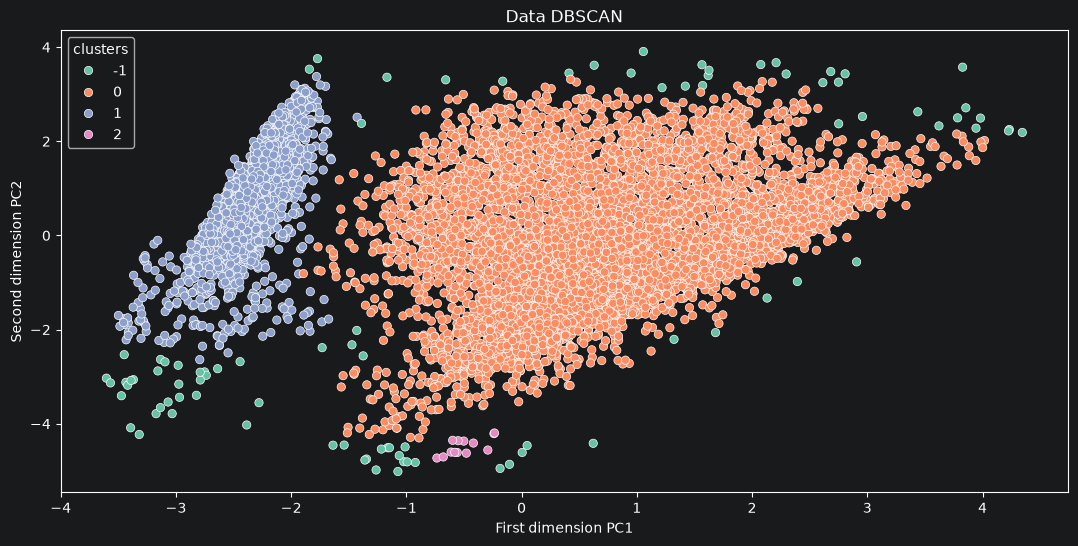

In [67]:
df_pca_dbscan = attach_labels(df_pca_dbscan, labels_dbscan, "clusters")


plt.figure(figsize=(13, 6))
sns.scatterplot(x="PC1", y="PC2", data=df_pca_dbscan, hue="clusters", palette="Set2")
plt.title("Data DBSCAN")
plt.xlabel("First dimension PC1")
plt.ylabel("Second dimension PC2")
plt.show()



## save the proccess dbscan

In [68]:
save_processed(df_clean, "df_clean_clusters.csv")


PosixPath('/home/ouelaimar/Desktop/CardProfiler/data/processed/df_clean_clusters.csv')

## create cluster_final

In [69]:
df_prepare_clustering = load_processed("df_prepare_clustering.csv")


labels_km, kmeans, pca_km, df_pca_km = fit_final_kmeans(df_prepare_clustering, n_components=3, k=3)
labels_db, dbscan, df_pca_db = fit_final_dbscan(df_prepare_clustering, n_components=3, eps=0.7, min_samples=10)

df_clean = attach_labels(df_clean, labels_km, "cluster_kmeans")
df_clean = attach_labels(df_clean, labels_db, "cluster_dbscan")
df_clean["est_atypique_dbscan"] = df_clean["cluster_dbscan"] == -1

comparison = compare_methods(df_pca_km, labels_km, df_pca_db, labels_db)
display(comparison)

method, reason = choose_method(comparison)
print(reason)

df_clean = set_cluster_final(df_clean, method)
print(df_clean["cluster_final"].isna().sum())                   # must be 0
print(df_clean["cluster_final"].value_counts(normalize=True))

,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise_pct,coverage_pct,min_cluster_pct,max_cluster_pct,is_balanced
method,,,,,,,,,
kmeans,3,0.3826,1.0043,6068.8,0.0,100.0,26.7,39.9,True
dbscan,1,NaN,NaN,NaN,0.3,99.7,100.0,100.0,False


* K-means retained: it classifies 100% of clients (needed for target). 
* DBSCAN silhouette = nan, noise = 0.3%, 
* balanced = False — not clearly better.

0
cluster_final
0    0.399039
2    0.333780
1    0.267181
Name: proportion, dtype: float64


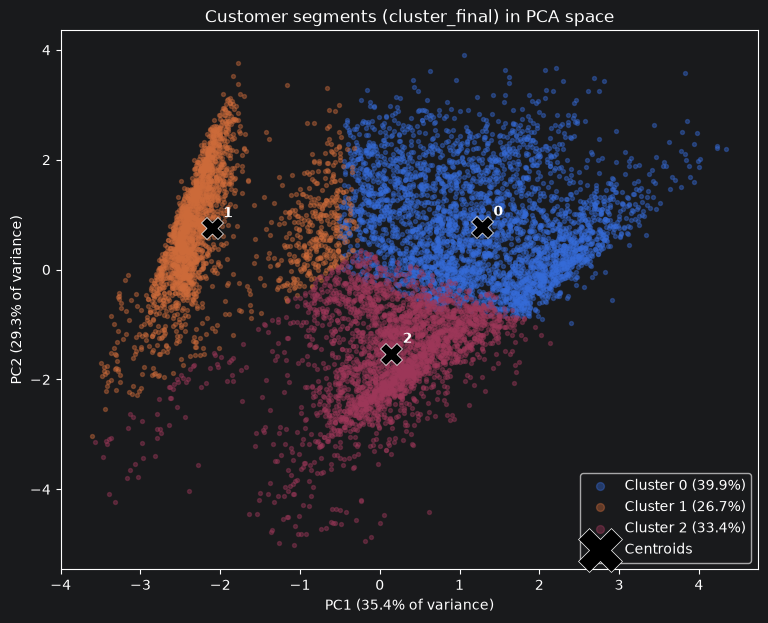

,PC1,PC2
0,1.29,0.78
1,-2.10,0.75
2,0.15,-1.53


In [70]:
ax, centroids = plot_clusters_2d(df_prepare_clustering, df_clean["cluster_final"])
ax.figure.savefig("../reports/clusters_scatter.png")
plt.show()
display(centroids.round(2))

## scatter plot

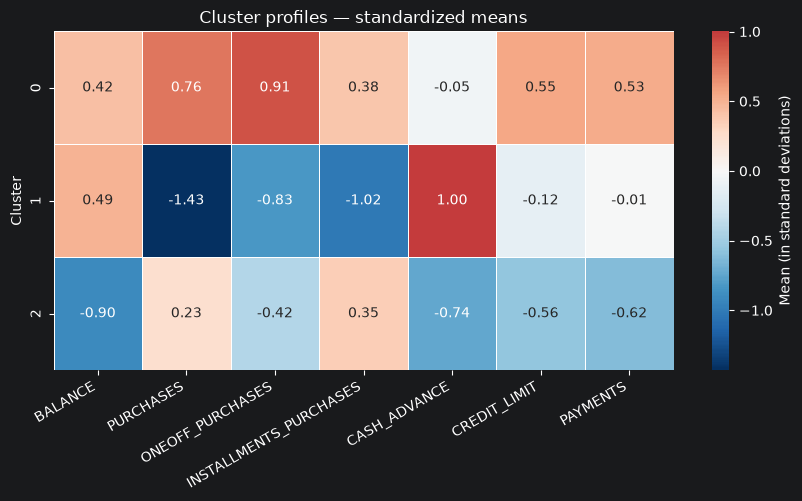

Cluster 0: highest → ['ONEOFF_PURCHASES', 'PURCHASES'] | lowest → ['INSTALLMENTS_PURCHASES', 'CASH_ADVANCE']
Cluster 1: highest → ['CASH_ADVANCE', 'BALANCE'] | lowest → ['INSTALLMENTS_PURCHASES', 'PURCHASES']
Cluster 2: highest → ['INSTALLMENTS_PURCHASES', 'PURCHASES'] | lowest → ['CASH_ADVANCE', 'BALANCE']
Means per cluster


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
cluster,,,,,,,
0,2191.0,2117.0,1382.0,735.0,1054.0,6350.0,2774.0
1,2175.0,19.0,13.0,6.0,2013.0,3986.0,1638.0
2,328.0,460.0,112.0,348.0,62.0,2683.0,565.0


Medians per cluster


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
cluster,,,,,,,
0,1370.0,1283.0,760.0,320.0,0.0,6000.0,1691.0
1,1500.0,0.0,0.0,0.0,1269.0,3000.0,766.0
2,68.0,317.0,0.0,225.0,0.0,2000.0,385.0


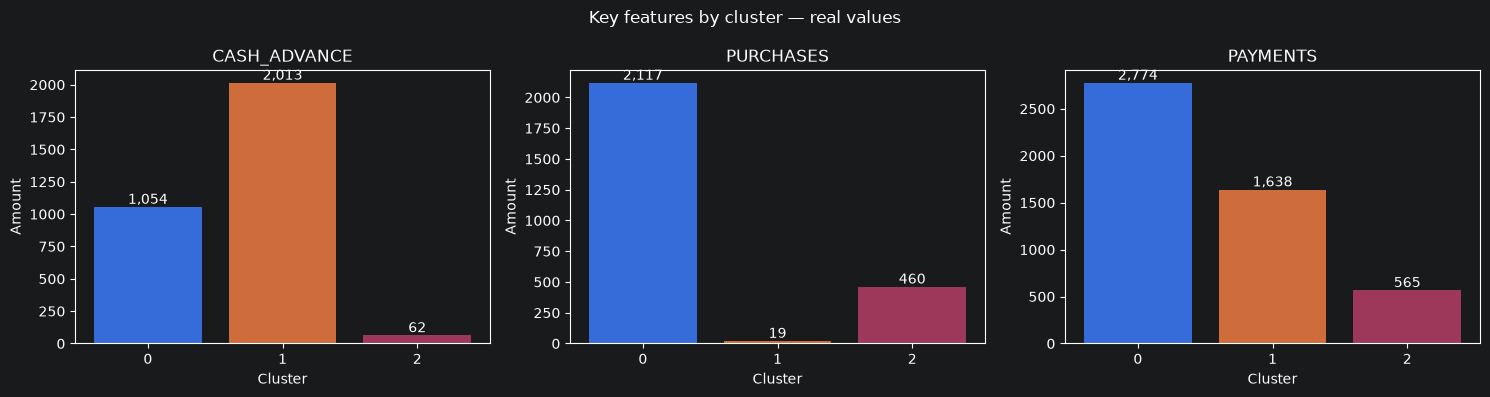

In [71]:

profile_std = cluster_profile_standardized(df_prepare_clustering, df_clean["cluster_final"])

plot_cluster_profile_heatmap(profile_std)
plt.show()

# The variables that best describe each cluster
for cluster, row in profile_std.iterrows():
    top = row.sort_values(ascending=False)
    print(f"Cluster {cluster}: highest → {list(top.index[:2])} | lowest → {list(top.index[-2:])}")

profile_mean = cluster_profile_real(df_clean, stat="mean")
profile_median = cluster_profile_real(df_clean, stat="median")

print("Means per cluster"); display(profile_mean)
print("Medians per cluster"); display(profile_median)

plot_key_features_by_cluster(profile_mean)
plt.show()

In [72]:
cluster_names = assign_names(profile_median)

cluster_names

{0: 'Clients Premium', 2: 'Clients à Faible Activité', 1: 'Clients à Risque'}

## cluster_names

In [73]:
df_clean = create_target(df_clean, cluster_names)
display(df_clean[["cluster_final", "target"]].head())
display(df_clean["target"].value_counts(normalize=True).round(3))

save_processed(df_clean, "df_clean_with_target.csv")

,cluster_final,target
0,2,Clients à Faible Activité
1,1,Clients à Risque
2,0,Clients Premium
3,2,Clients à Faible Activité
4,2,Clients à Faible Activité


target
Clients Premium              0.399
Clients à Faible Activité    0.334
Clients à Risque             0.267
Name: proportion, dtype: float64

PosixPath('/home/ouelaimar/Desktop/CardProfiler/data/processed/df_clean_with_target.csv')

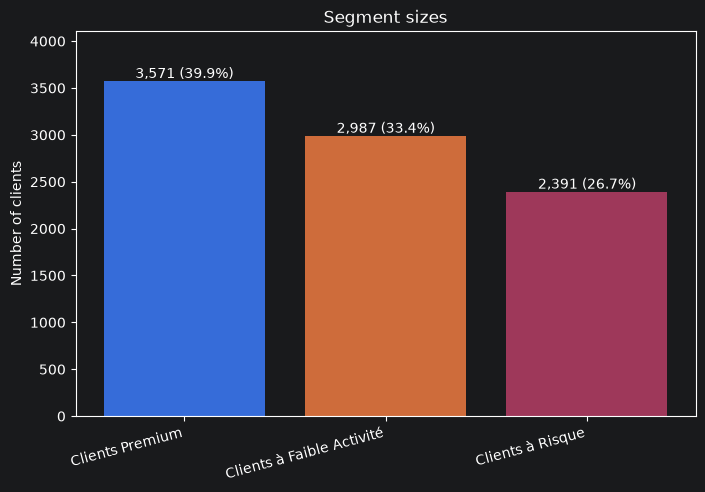

In [79]:
plot_segment_sizes(df_clean)
plt.show()

## check the results

In [82]:
df = load_processed("df_clean_with_target.csv")
print(df.shape)                                         # ~8,949 rows
print(df["target"].isna().sum())                        # must be 0
print(df["target"].value_counts(normalize=True) * 100)  # 3 segments, none < ~10%

(8949, 12)
0
target
Clients Premium              39.903900
Clients à Faible Activité    33.378031
Clients à Risque             26.718069
Name: proportion, dtype: float64
